# EDA Notebook — InSDN Dataset

Notebook này dùng để **khám phá dữ liệu network traffic của InSDN** trước khi preprocessing và train model.

Mục tiêu chính:

- Kiểm tra cấu trúc dataset
- Kiểm tra missing / infinity / duplicate
- Phân bố `Label`
- Class imbalance
- Phân bố các network-flow features
- Protocol / Port behavior
- So sánh feature giữa Normal và Attack
- Correlation giữa các feature
- Kiểm tra nguy cơ data leakage từ IP / Port / Flow ID / Timestamp
- Phân tích traffic theo thời gian
- Chuẩn bị hướng preprocessing cho ML

> Lưu ý: EDA chỉ để hiểu data. Không fit scaler/encoder trên toàn dataset trước khi train/test split.

## 1. Import thư viện

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## 2. Khai báo đường dẫn dataset

Sau khi download InSDN từ Kaggle và giải nén, thư mục thường chứa:

```text
InSDN_DatasetCSV/
├── Normal_data.csv
├── OVS.csv
└── metasploitable-2.csv
```

Chỉnh `DATA_DIR` nếu folder của bạn khác.

In [2]:
DATA_DIR = Path("/kaggle/input/datasets/badcodebuilder/insdn-dataset/InSDN_DatasetCSV")

csv_files = sorted(DATA_DIR.glob("*.csv"))
csv_files

[PosixPath('/kaggle/input/datasets/badcodebuilder/insdn-dataset/InSDN_DatasetCSV/Normal_data.csv'),
 PosixPath('/kaggle/input/datasets/badcodebuilder/insdn-dataset/InSDN_DatasetCSV/OVS.csv'),
 PosixPath('/kaggle/input/datasets/badcodebuilder/insdn-dataset/InSDN_DatasetCSV/metasploitable-2.csv')]

## 3. Load và merge các CSV

Thêm cột `__source_file` để sau này xem từng file CSV chứa class nào.

In [3]:
frames = []

for file in csv_files:
    temp = pd.read_csv(file, low_memory=False)
    temp.columns = (
        pd.Index(temp.columns)
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )
    temp["__source_file"] = file.name
    frames.append(temp)

df = pd.concat(frames, ignore_index=True, sort=False)

if "Label" in df.columns:
    df["Label"] = (
        df["Label"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)
    )

print("Shape:", df.shape)
df.head()

Shape: (343889, 85)


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,__source_file
0,185.127.17.56-192.168.20.133-443-53648-6,185.127.17.56,443,192.168.20.133,53648,6,5/2/2020 13:58,245230,44,40,124937.0,1071.0,9100,0,2839.477273,1839.508257,517,0,26.775000,109.188026,513835.99070,342.535579,2954.578313,7953.221927,64066.0,-44.0,238564.0,5548.000000,10446.29576,64066.0,2.0,245230.0,6287.948718,12986.46879,79070.0,29.0,0,0,0,0,880,804,179.423398,163.112180,0,9100,1482.447059,1933.268313,3.737526e+06,0,1,0,0,1,0,0,0,0,1500.095238,2839.477273,26.775000,0,0,0,0,0,0,44,124937,40,1071,-1,65535,41,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal_data.csv
1,185.127.17.56-192.168.20.133-443-53650-6,192.168.20.133,53650,185.127.17.56,443,6,5/2/2020 13:58,1605449,107,149,1071.0,439537.0,517,0,10.009346,67.496680,27300,0,2949.912752,3012.589539,274445.34210,159.456949,6295.878431,56408.330520,859760.0,-102.0,1332121.0,12567.179250,83434.14155,861138.0,2.0,1603130.0,10831.959460,73926.65245,861129.0,1.0,0,0,0,0,2140,3004,66.648022,92.808928,0,27300,1714.428016,2713.465917,7.362897e+06,0,1,0,0,0,0,0,0,1,1721.125000,10.009346,2949.912752,0,0,0,0,0,0,107,1071,149,439537,-1,64240,4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal_data.csv
2,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.133,35108,192.168.20.2,53,6,5/2/2020 13:58,53078,5,5,66.0,758.0,66,0,13.200000,29.516097,638,0,151.600000,276.826299,15524.32269,188.401974,5897.555556,15184.845200,46232.0,19.0,50302.0,12575.500000,22521.87727,46251.0,67.0,52962.0,13240.500000,22052.04405,46258.0,405.0,0,0,0,0,100,124,94.200987,94.200987,0,638,74.909091,190.807471,3.640749e+04,0,1,0,0,0,0,0,0,1,82.400000,13.200000,151.600000,0,0,0,0,0,0,5,66,5,758,-1,64240,1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal_data.csv
3,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.2,53,192.168.20.133,35108,6,5/2/2020 13:58,6975,1,1,0.0,0.0,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0.00000,286.738351,6975.000000,0.000000,6975.0,6975.0,0.0,0.000000,0.00000,0.0,0.0,0.0,0.000000,0.00000,0.0,0.0,0,0,0,0,20,20,143.369176,143.369176,0,0,0.000000,0.000000,0.000000e+00,0,0,0,0,1,0,0,0,1,0.000000,0.000000,0.000000,0,0,0,0,0,0,1,0,1,0,-1,64239,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal_data.csv
4,154.59.122.74-192.168.20.133-443-60900-6,192.168.20.133,60900,154.59.122.74,443,6,5/2/2020 13:58,190141,13,16,780.0,11085.0,427,0,60.000000,130.042942,2596,0,692.812500,794.157350,62401.06027,152.518394,6790.750000,12933.295910,38521.0,-54.0,86882.0,7240.166667,13050.84163,38805.0,1.0,190141.0,12676.066670,15949.09279,38521.0,1.0,0,0,0,0,260,344,68.370315,84.148080,0,2596,395.500000,661.691706,4.378359e+05,0,1,0,0,0,0,0,0,1,409.137931,60.000000,692.812500,0,0,0,0,0,0,13,780,16,11085,-1,64240,3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal,Normal_data.csv


## 4. Tổng quan dataset

In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1024**2, 2))

display(
    pd.DataFrame({
        "column": df.columns,
        "dtype": [str(df[c].dtype) for c in df.columns],
        "n_unique": [df[c].nunique(dropna=False) for c in df.columns],
    })
)

Rows: 343889
Columns: 85
Memory usage (MB): 335.88


,column,dtype,n_unique
0,Flow ID,object,234971
1,Src IP,object,122868
2,Src Port,int64,28273
3,Dst IP,object,1081
4,Dst Port,int64,29695
5,Protocol,int64,3
6,Timestamp,object,1392
7,Flow Duration,int64,85380
8,Tot Fwd Pkts,int64,569
9,Tot Bwd Pkts,int64,699


## 5. Missing values, Infinity và Duplicate

Với network-flow dataset, `Flow Byts/s`, `Flow Pkts/s` hoặc các rate feature đôi khi có thể có `inf` do duration bằng 0.

In [5]:
missing = df.isna().sum().sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing / len(df) * 100
})

display(missing_table[missing_table["missing_count"] > 0].head(30))

print("Duplicate rows:", df.duplicated().sum())

numeric_df = df.select_dtypes(include=np.number)
inf_counts = pd.Series(
    np.isinf(numeric_df.to_numpy()).sum(axis=0),
    index=numeric_df.columns
).sort_values(ascending=False)

display(inf_counts[inf_counts > 0].to_frame("inf_count").head(30))

,missing_count,missing_pct


Duplicate rows: 1


,inf_count


## 6. Phân bố class

Đây là một trong các phần quan trọng nhất của InSDN vì dataset bị **class imbalance mạnh**.

In [6]:
label_counts = df["Label"].value_counts()
label_pct = df["Label"].value_counts(normalize=True) * 100

class_table = pd.DataFrame({
    "count": label_counts,
    "percentage": label_pct
})

display(class_table)

,count,percentage
Label,,
DDoS,121942,35.459698
Probe,98129,28.535080
Normal,68424,19.897118
DoS,53616,15.591077
BFA,1405,0.408562
Web-Attack,192,0.055832
BOTNET,164,0.047690
U2R,17,0.004943


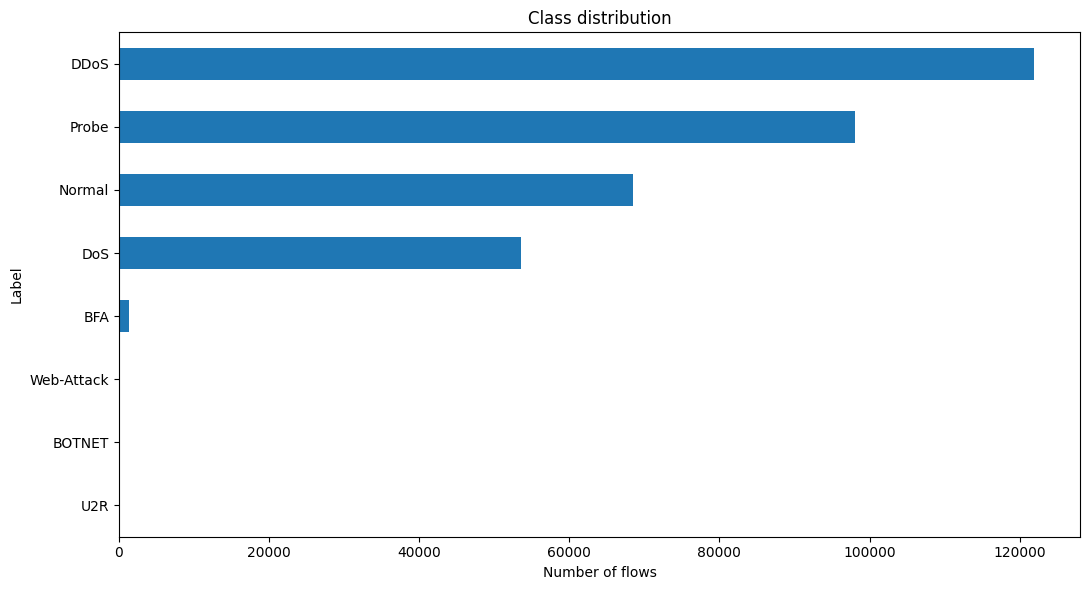

In [7]:
plt.figure(figsize=(11, 6))
label_counts.sort_values().plot(kind="barh")
plt.title("Class distribution")
plt.xlabel("Number of flows")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

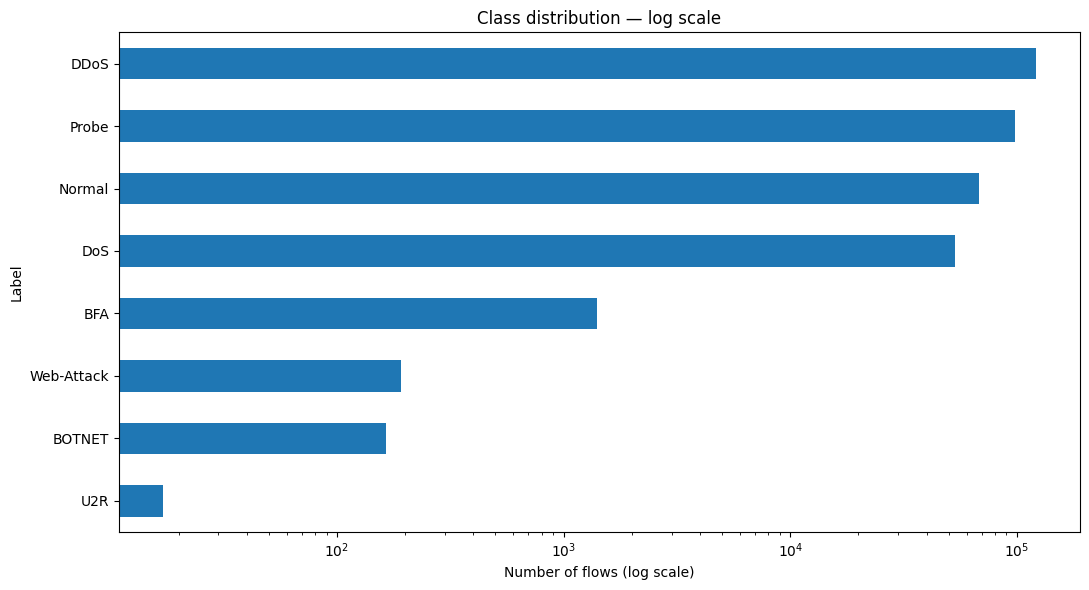

In [8]:
plt.figure(figsize=(11, 6))
label_counts.sort_values().plot(kind="barh", logx=True)
plt.title("Class distribution — log scale")
plt.xlabel("Number of flows (log scale)")
plt.ylabel("Label")
plt.tight_layout()
plt.show()

### Nhận xét cần ghi lại

Sau khi chạy cell trên, chú ý:

- Class nào chiếm đa số?
- Class nào rất ít sample?
- Accuracy có thể misleading không?
- Có cần macro-F1 / recall từng class không?

## 7. Dataset source vs Label

InSDN được ghép từ nhiều CSV. Ta cần xem class có bị gắn quá chặt với từng file hay không.

In [9]:
source_label = pd.crosstab(df["__source_file"], df["Label"])
display(source_label)

Label,BFA,BOTNET,DDoS,DoS,Normal,Probe,U2R,Web-Attack
__source_file,,,,,,,,
Normal_data.csv,0,0,0,0,68424,0,0,0
OVS.csv,1110,164,48413,52471,0,36372,0,192
metasploitable-2.csv,295,0,73529,1145,0,61757,17,0


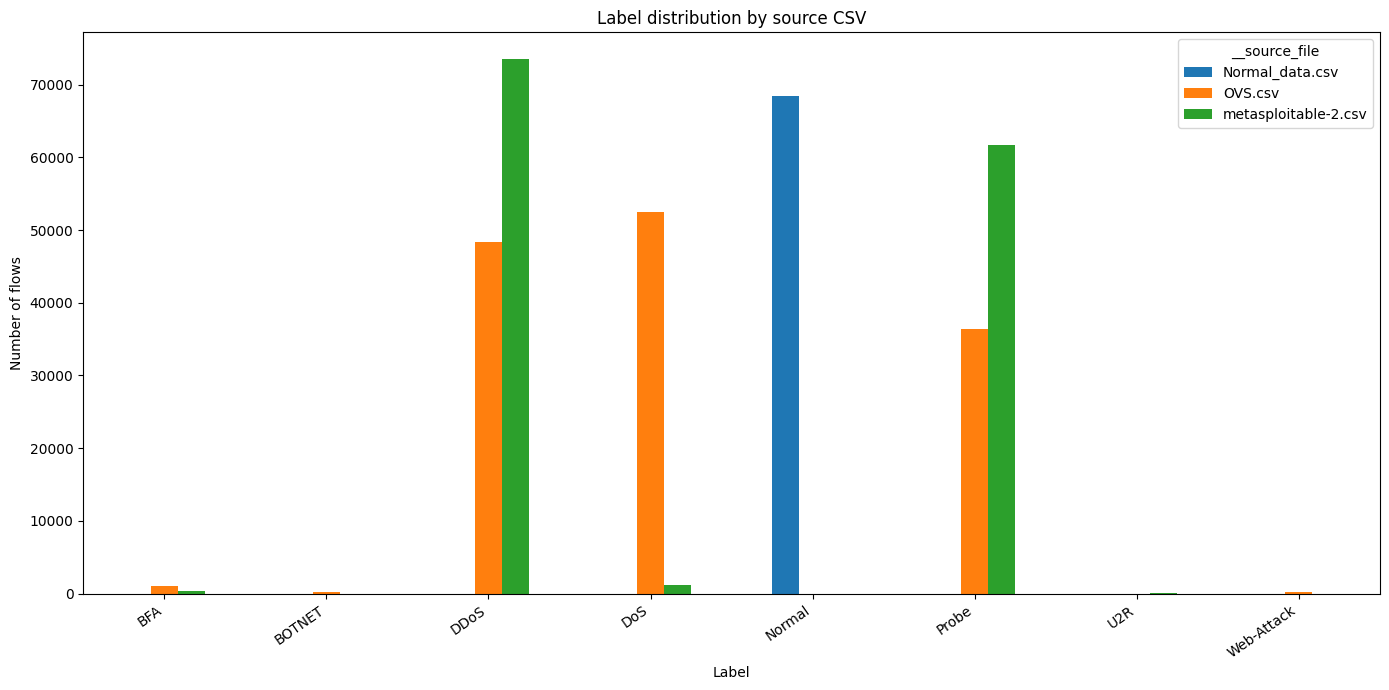

In [10]:
source_label.T.plot(kind="bar", figsize=(14, 7))
plt.title("Label distribution by source CSV")
plt.xlabel("Label")
plt.ylabel("Number of flows")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

Nếu một attack chỉ xuất hiện trong đúng một source file, random split có thể làm model học các đặc trưng đặc thù của scenario đó.

## 8. Identifier / topology features

Các cột dưới đây có nguy cơ khiến model học thuộc topology của lab thay vì học behavior:

- `Flow ID`
- `Src IP`
- `Dst IP`
- `Src Port`
- `Dst Port`
- `Timestamp`

Không tự động xóa ở bước EDA. Trước tiên cần kiểm tra.

In [11]:
identifier_candidates = [
    "Flow ID",
    "Src IP",
    "Dst IP",
    "Src Port",
    "Dst Port",
    "Timestamp"
]

identifier_rows = []

for col in identifier_candidates:
    if col in df.columns:
        identifier_rows.append({
            "column": col,
            "unique_values": df[col].nunique(dropna=False),
            "unique_ratio": df[col].nunique(dropna=False) / len(df)
        })

display(pd.DataFrame(identifier_rows))

,column,unique_values,unique_ratio
0,Flow ID,234971,0.683276
1,Src IP,122868,0.357290
2,Dst IP,1081,0.003143
3,Src Port,28273,0.082215
4,Dst Port,29695,0.086351
5,Timestamp,1392,0.004048


### Kiểm tra một IP / Port có gắn với đúng một label không

Nếu rất nhiều IP hoặc port chỉ xuất hiện trong một class, đó là dấu hiệu model có thể học signature/topology.

In [12]:
leakage_rows = []

for col in ["Src IP", "Dst IP", "Src Port", "Dst Port", "Protocol"]:
    if col not in df.columns:
        continue

    label_per_value = df.groupby(col)["Label"].nunique()

    leakage_rows.append({
        "column": col,
        "unique_values": len(label_per_value),
        "values_seen_in_only_one_label": (label_per_value == 1).sum(),
        "single_label_pct": 100 * (label_per_value == 1).mean()
    })

display(pd.DataFrame(leakage_rows))

,column,unique_values,values_seen_in_only_one_label,single_label_pct
0,Src IP,122868,122862,99.995117
1,Dst IP,1081,1071,99.074931
2,Src Port,28273,9784,34.605454
3,Dst Port,29695,23190,78.093955
4,Protocol,3,0,0.000000


## 9. Top Source IP / Destination IP

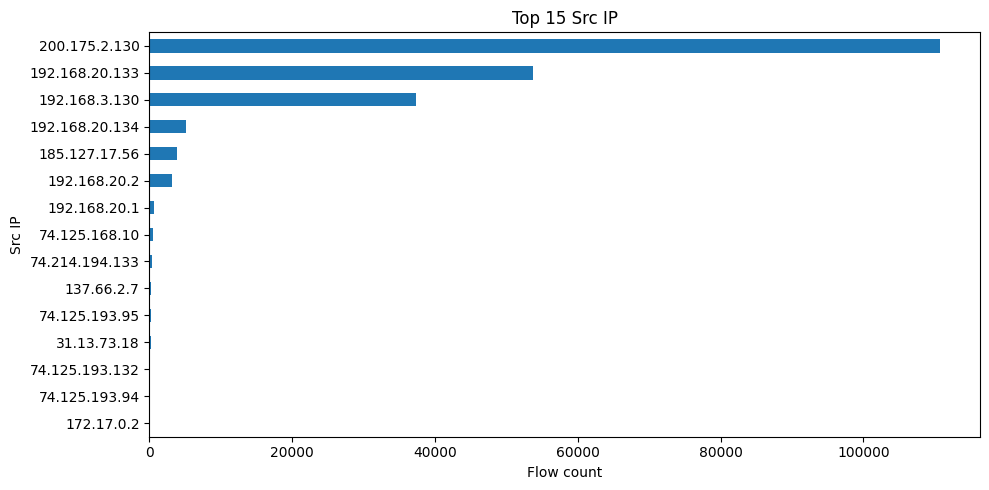

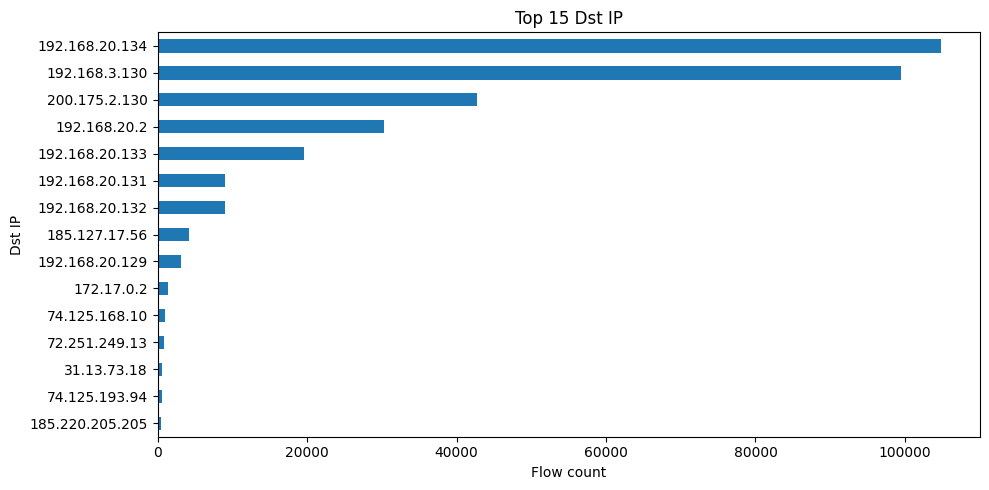

In [13]:
for col in ["Src IP", "Dst IP"]:
    if col in df.columns:
        top = df[col].value_counts().head(15)

        plt.figure(figsize=(10, 5))
        top.sort_values().plot(kind="barh")
        plt.title(f"Top 15 {col}")
        plt.xlabel("Flow count")
        plt.tight_layout()
        plt.show()

## 10. Protocol distribution

,count
Protocol,
6,188024
0,121856
17,34009


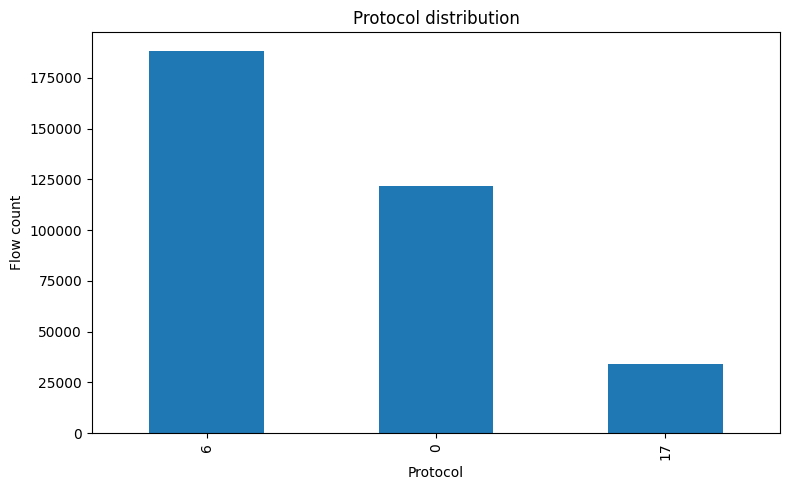

In [14]:
if "Protocol" in df.columns:
    protocol_counts = df["Protocol"].value_counts()

    display(protocol_counts.to_frame("count"))

    plt.figure(figsize=(8, 5))
    protocol_counts.plot(kind="bar")
    plt.title("Protocol distribution")
    plt.xlabel("Protocol")
    plt.ylabel("Flow count")
    plt.tight_layout()
    plt.show()

## 11. Protocol vs Label

Label,BFA,BOTNET,DDoS,DoS,Normal,Probe,U2R,Web-Attack
Protocol,,,,,,,,
0,0,0,121439,0,389,28,0,0
6,1404,164,500,53555,34115,98078,16,192
17,1,0,3,61,33920,23,1,0


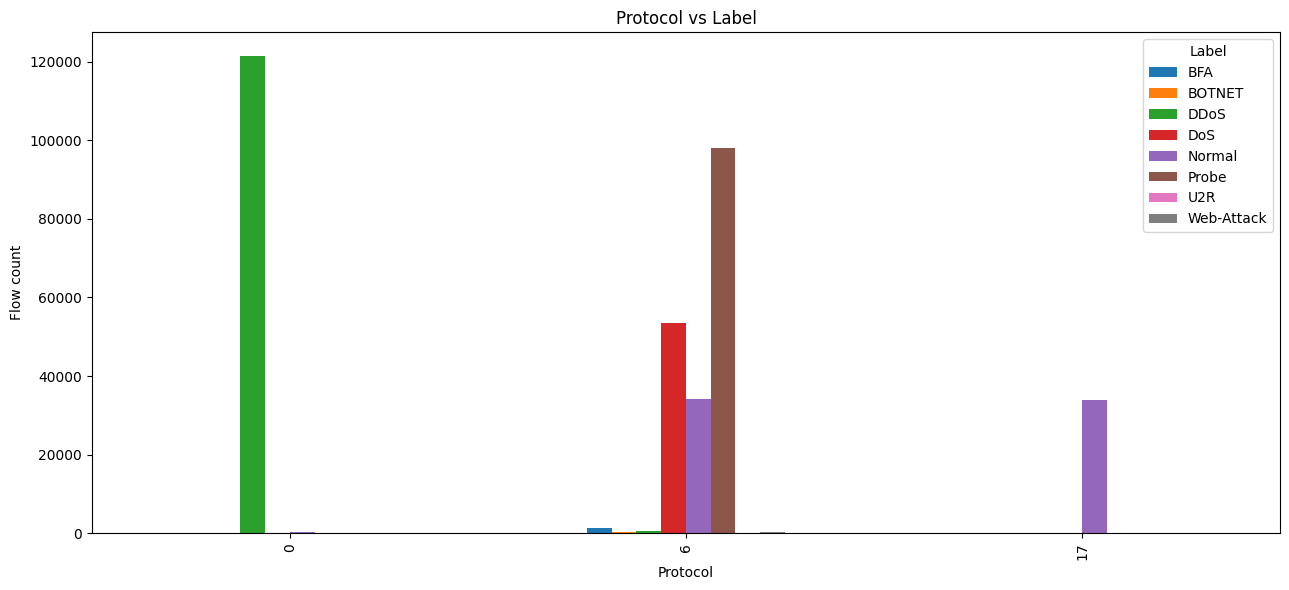

In [15]:
if "Protocol" in df.columns:
    protocol_label = pd.crosstab(df["Protocol"], df["Label"])
    display(protocol_label)

    protocol_label.plot(kind="bar", figsize=(13, 6))
    plt.title("Protocol vs Label")
    plt.xlabel("Protocol")
    plt.ylabel("Flow count")
    plt.tight_layout()
    plt.show()

## 12. Top Source / Destination Ports

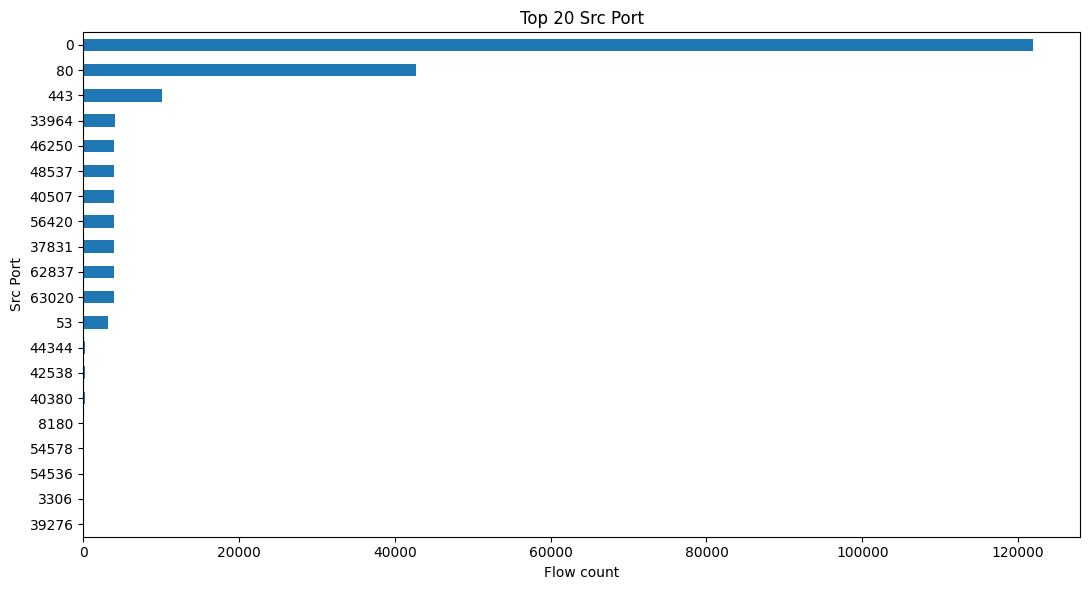

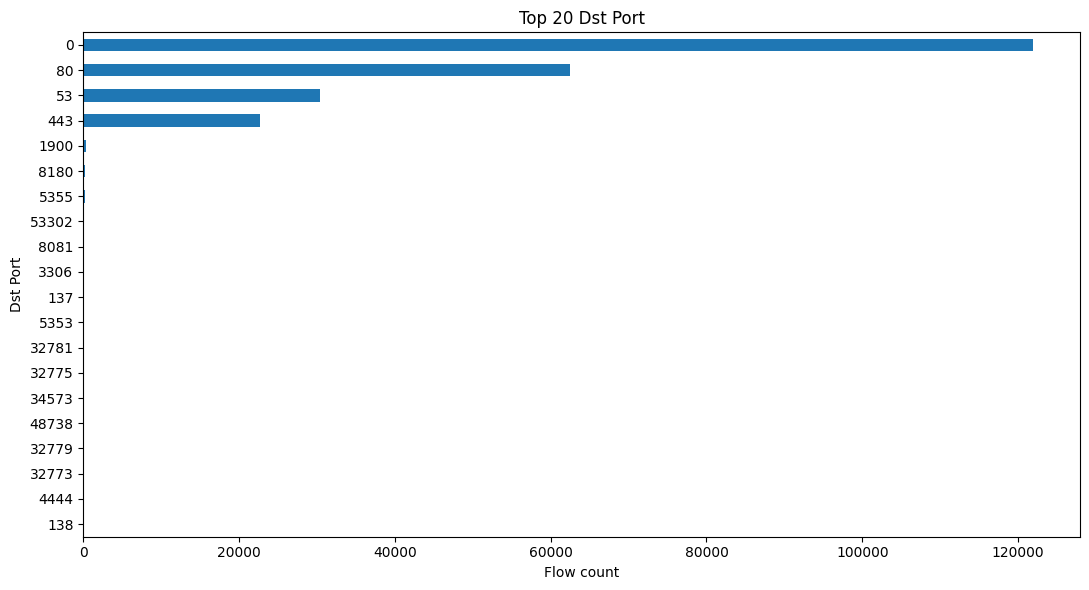

In [16]:
for col in ["Src Port", "Dst Port"]:
    if col in df.columns:
        top = df[col].value_counts().head(20)

        plt.figure(figsize=(11, 6))
        top.sort_values().plot(kind="barh")
        plt.title(f"Top 20 {col}")
        plt.xlabel("Flow count")
        plt.tight_layout()
        plt.show()

## 13. Các network-flow features quan trọng

Ta ưu tiên xem các feature có ý nghĩa behavior hơn identifier.

In [17]:
important_features = [
    "Flow Duration",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts",
    "TotLen Fwd Pkts",
    "TotLen Bwd Pkts",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Flow IAT Mean",
    "Flow IAT Std",
    "Fwd Pkts/s",
    "Bwd Pkts/s",
    "Pkt Len Mean",
    "Pkt Len Std",
    "Pkt Len Var",
    "Pkt Size Avg",
    "SYN Flag Cnt",
    "ACK Flag Cnt",
    "RST Flag Cnt",
    "Active Mean",
    "Idle Mean"
]

available_features = [c for c in important_features if c in df.columns]

available_features

['Flow Duration',
 'Tot Fwd Pkts',
 'Tot Bwd Pkts',
 'TotLen Fwd Pkts',
 'TotLen Bwd Pkts',
 'Flow Byts/s',
 'Flow Pkts/s',
 'Flow IAT Mean',
 'Flow IAT Std',
 'Fwd Pkts/s',
 'Bwd Pkts/s',
 'Pkt Len Mean',
 'Pkt Len Std',
 'Pkt Len Var',
 'Pkt Size Avg',
 'SYN Flag Cnt',
 'ACK Flag Cnt',
 'RST Flag Cnt',
 'Active Mean',
 'Idle Mean']

## 14. Numeric summary

Network traffic thường long-tail, nên median và percentile 95/99 thường hữu ích hơn mean.

In [18]:
numeric_summary = (
    df[available_features]
    .replace([np.inf, -np.inf], np.nan)
    .describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99])
    .T
)

display(numeric_summary)

,count,mean,std,min,1%,5%,50%,95%,99%,max
Flow Duration,343889.0,6.737171e+06,2.183354e+07,-154.00000,1.000000,1.000000,2530.000000,6.215463e+07,1.156739e+08,1.200000e+08
Tot Fwd Pkts,343889.0,6.160331e+00,1.554169e+03,0.00000,0.000000,0.000000,0.000000,6.000000e+00,3.300000e+01,9.107480e+05
Tot Bwd Pkts,343889.0,6.119012e+00,1.058634e+02,1.00000,1.000000,1.000000,2.000000,7.000000e+00,3.500000e+01,3.409400e+04
TotLen Fwd Pkts,343889.0,7.310557e+02,6.965289e+04,0.00000,0.000000,0.000000,0.000000,1.022600e+03,7.800000e+03,3.160000e+07
TotLen Bwd Pkts,343889.0,8.335005e+03,3.429719e+05,0.00000,0.000000,0.000000,0.000000,1.898000e+03,3.913700e+04,1.070000e+08
Flow Byts/s,343889.0,7.453962e+04,6.627308e+05,-262711.86440,0.000000,0.000000,0.000000,2.014434e+05,1.792967e+06,8.630000e+07
Flow Pkts/s,343889.0,2.473059e+05,5.655406e+05,-16949.15254,0.142100,0.163102,1339.584729,2.000000e+06,2.000000e+06,3.000000e+06
Flow IAT Mean,343889.0,5.695235e+05,2.136013e+06,-154.00000,1.000000,1.000000,1026.333333,6.812587e+06,7.814562e+06,1.190000e+08
Flow IAT Std,343889.0,1.572945e+06,5.401988e+06,0.00000,0.000000,0.000000,0.000000,2.040000e+07,2.190000e+07,6.240000e+07
Fwd Pkts/s,343889.0,2.201005e+03,3.434216e+04,0.00000,0.000000,0.000000,0.000000,2.164502e+03,2.985075e+04,1.000000e+06


## 15. Distribution của các feature chính

Chỉ **clip phần hiển thị ở percentile 99** để biểu đồ dễ nhìn.

Không thay đổi raw data.

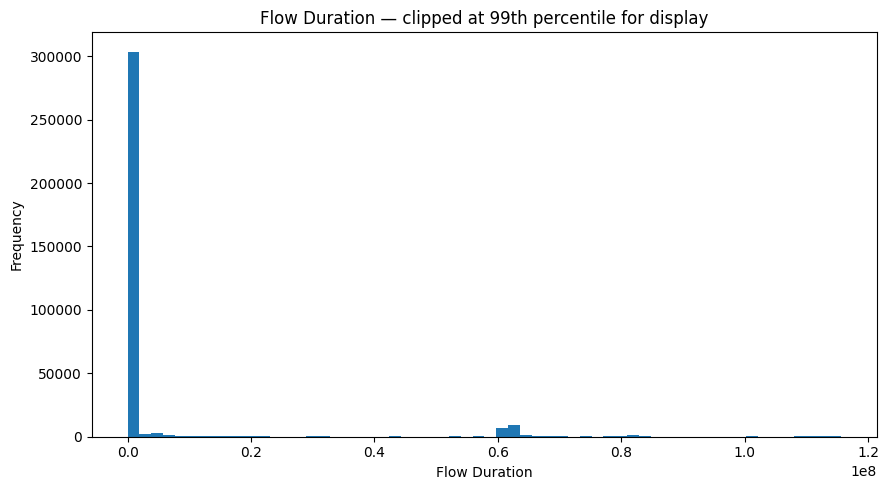

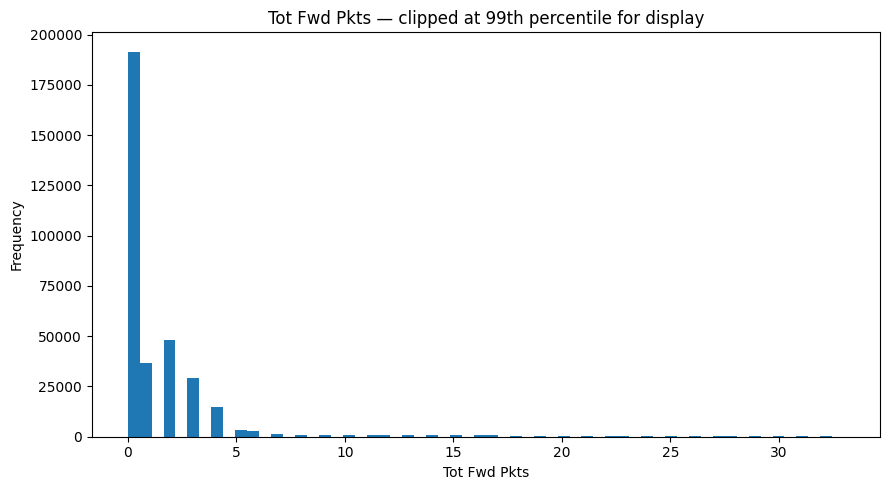

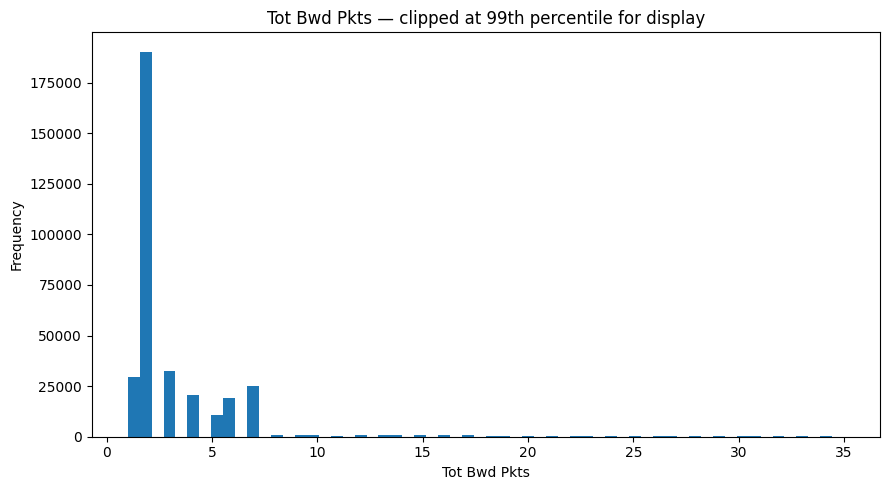

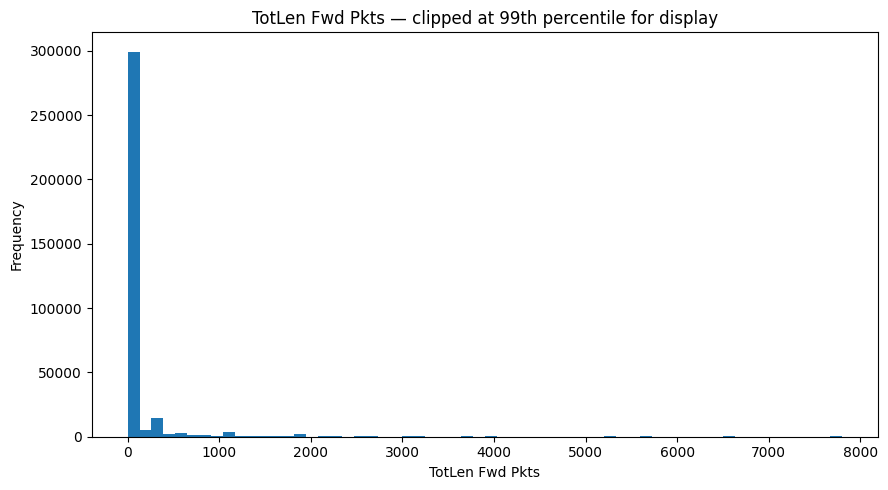

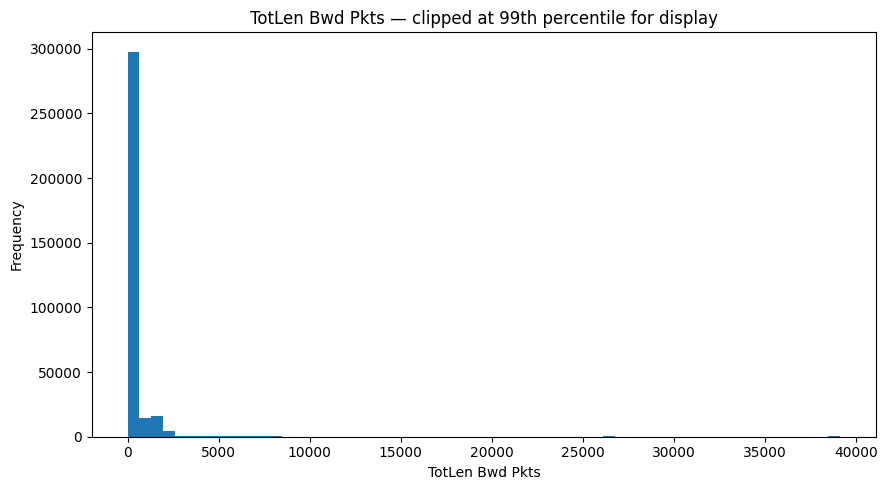

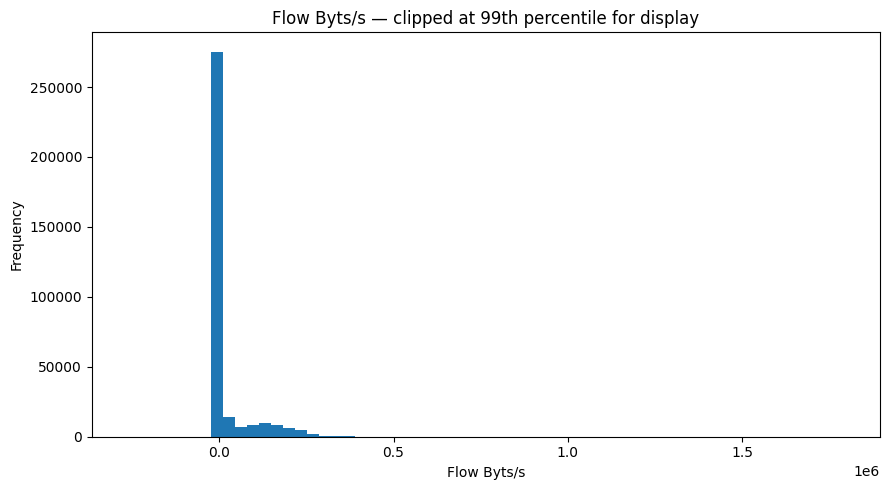

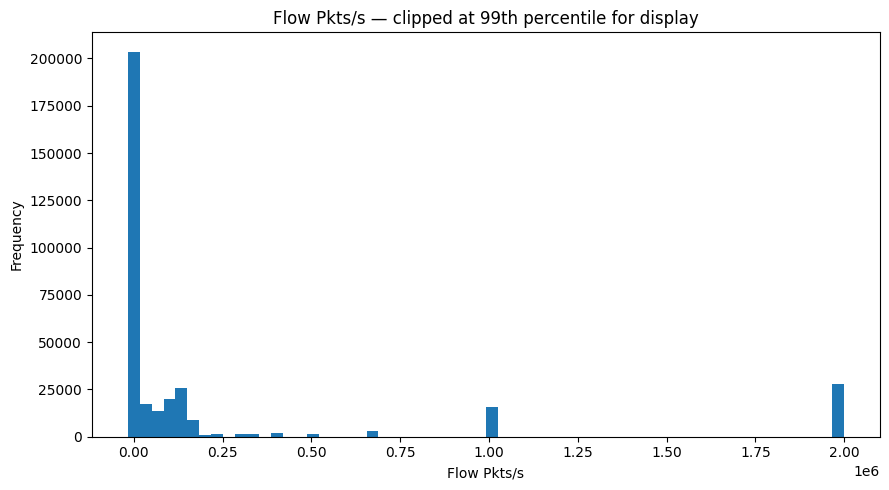

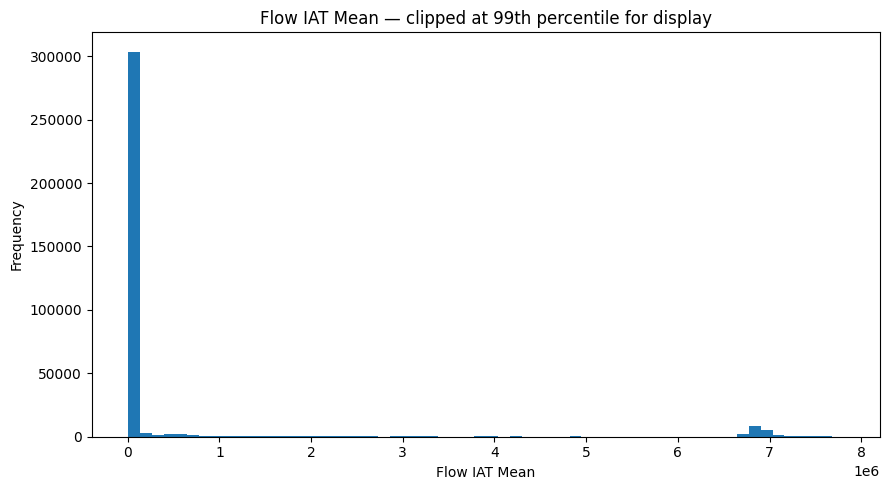

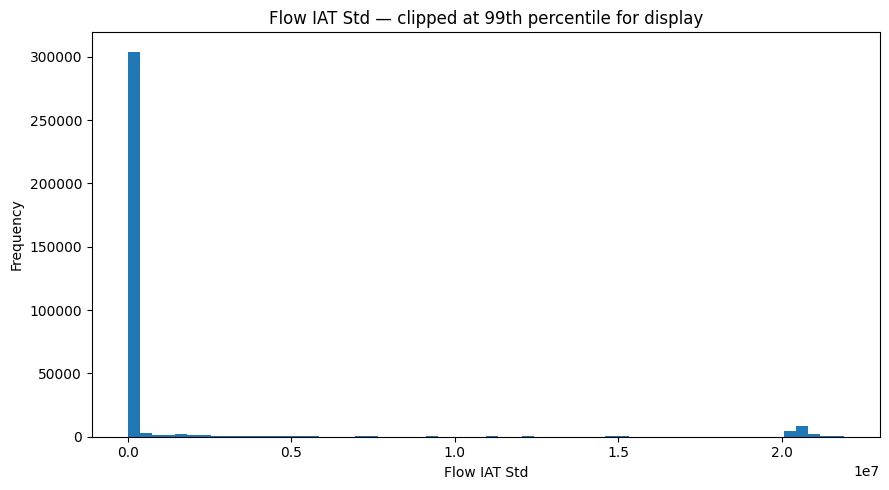

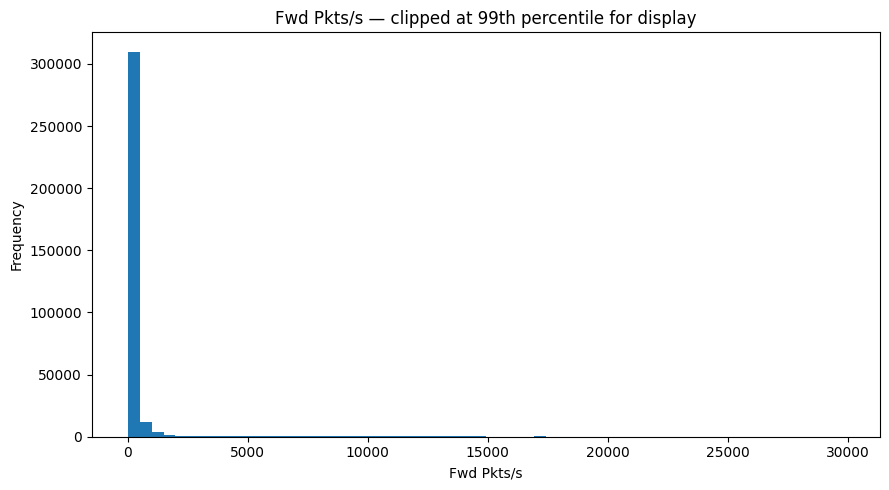

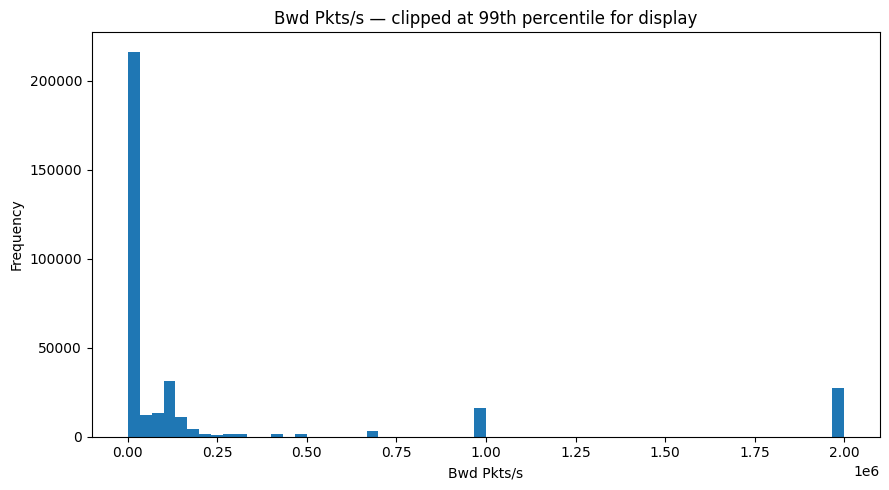

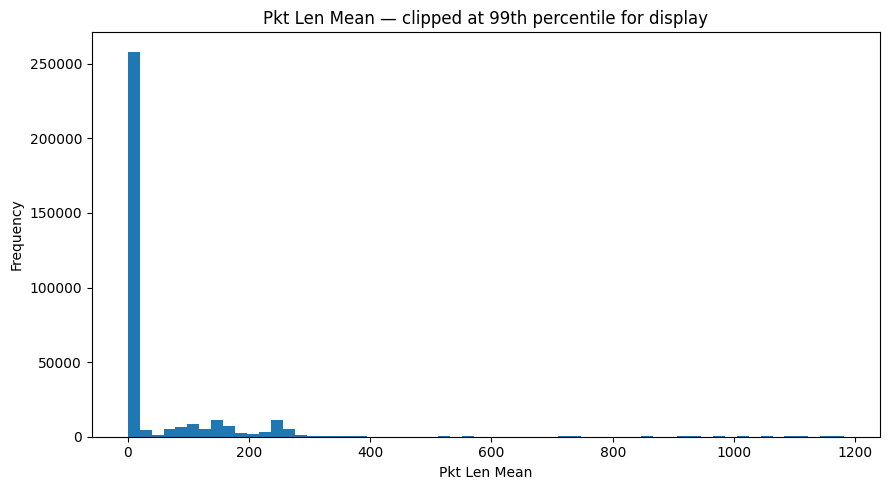

In [19]:
features_to_plot = available_features[:12]

for col in features_to_plot:
    values = pd.to_numeric(df[col], errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan).dropna()

    if len(values) == 0:
        continue

    upper = values.quantile(0.99)
    display_values = values[values <= upper]

    plt.figure(figsize=(9, 5))
    plt.hist(display_values, bins=60)
    plt.title(f"{col} — clipped at 99th percentile for display")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 16. Log transform để nhìn long-tail rõ hơn

Ví dụ với `Flow Byts/s`, `Flow Pkts/s`, packet length hoặc duration.

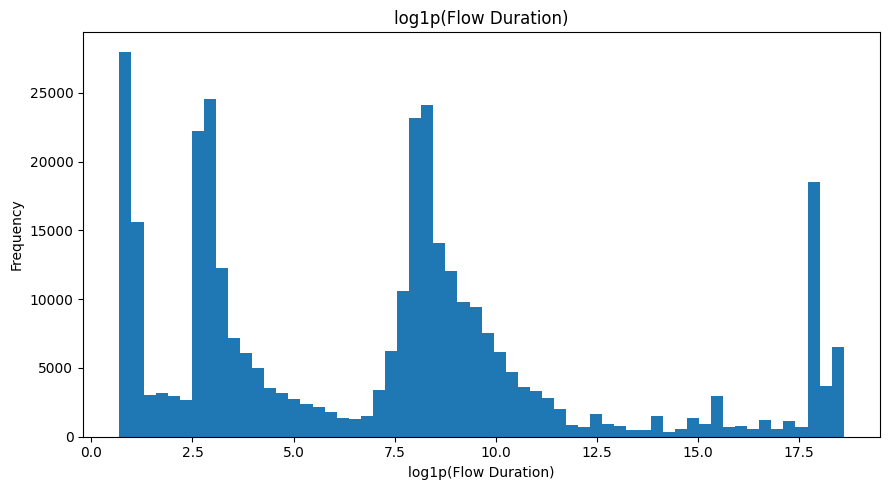

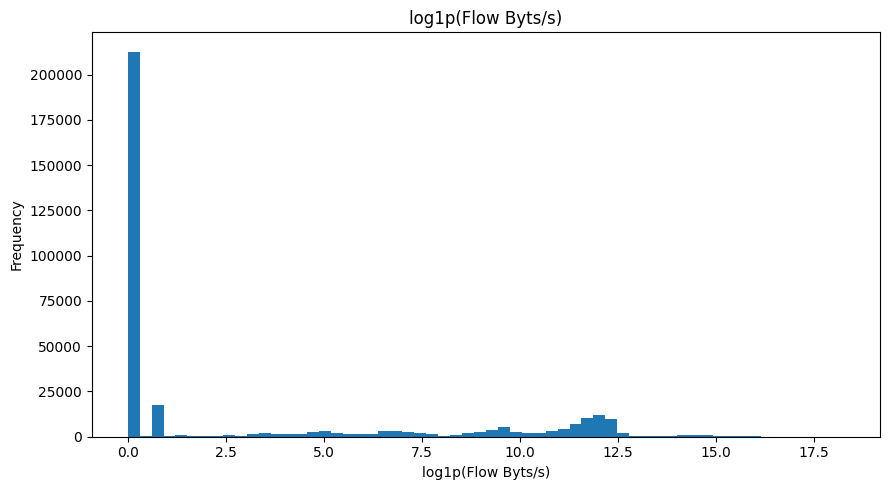

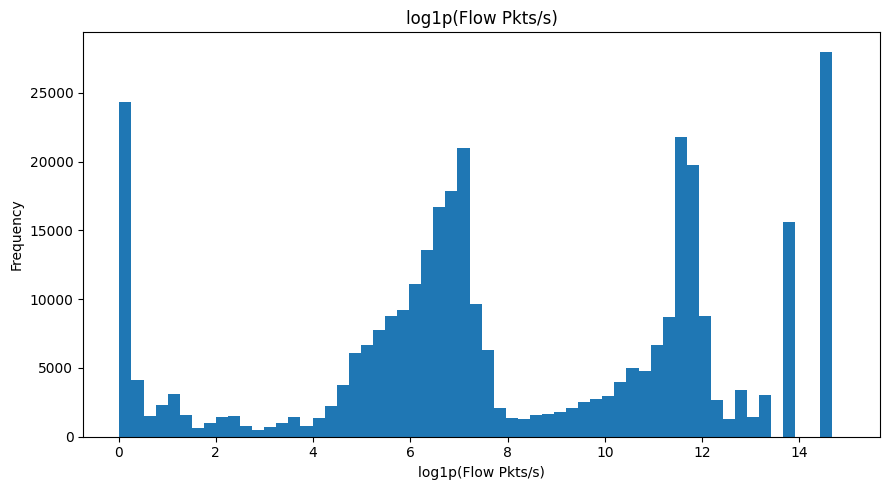

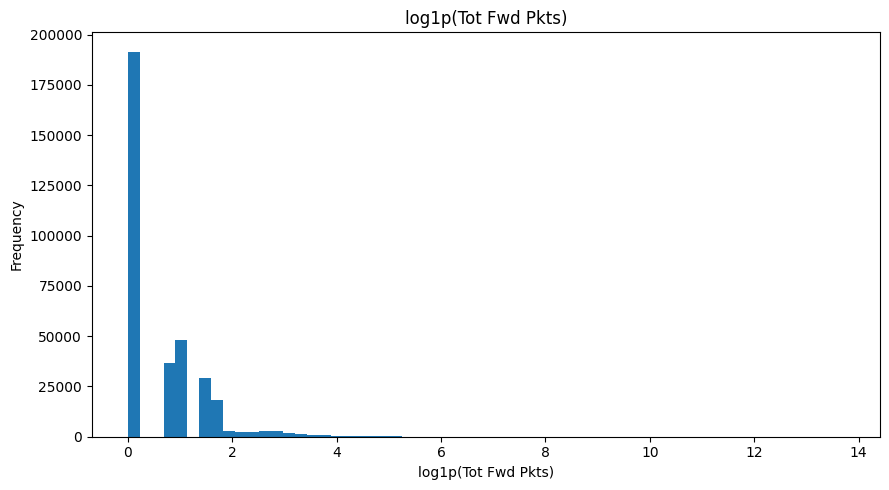

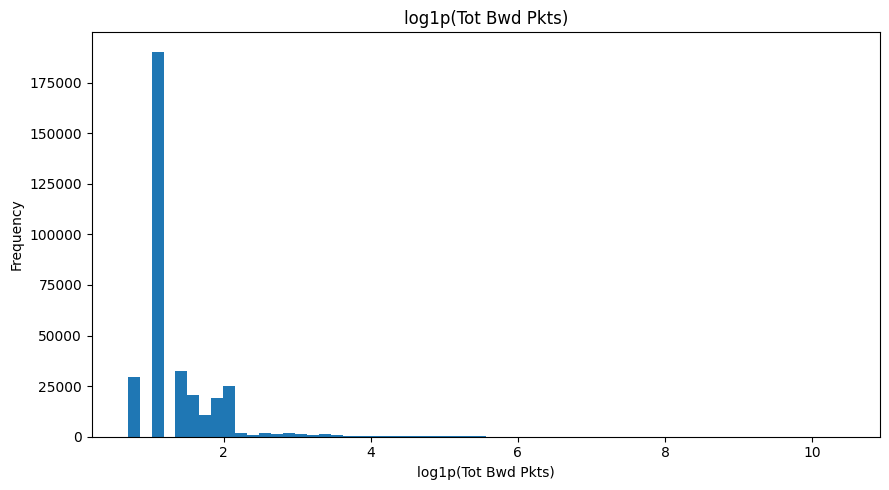

In [20]:
log_candidates = [
    "Flow Duration",
    "Flow Byts/s",
    "Flow Pkts/s",
    "Tot Fwd Pkts",
    "Tot Bwd Pkts"
]

for col in log_candidates:
    if col not in df.columns:
        continue

    values = pd.to_numeric(df[col], errors="coerce")
    values = values.replace([np.inf, -np.inf], np.nan)
    values = values[values >= 0].dropna()

    transformed = np.log1p(values)

    plt.figure(figsize=(9, 5))
    plt.hist(transformed, bins=60)
    plt.title(f"log1p({col})")
    plt.xlabel(f"log1p({col})")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 17. Feature median theo Label

Median thường phù hợp hơn mean với network-flow data vì distribution rất skewed.

In [21]:
label_medians = (
    df.groupby("Label")[available_features]
    .median(numeric_only=True)
)

display(label_medians)

,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Mean,Pkt Len Std,Pkt Len Var,Pkt Size Avg,SYN Flag Cnt,ACK Flag Cnt,RST Flag Cnt,Active Mean,Idle Mean
Label,,,,,,,,,,,,,,,,,,,,
BFA,17398.0,2.0,2.0,0.0,0.0,0.000000,358.873138,4054.000000,4551.288814,22.062636,238.390388,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0
BOTNET,36435.5,2.5,2.5,101.5,64.0,5015.303495,146.296051,22293.071428,497.088978,73.148026,73.148026,18.388889,37.674409,2838.722222,20.687500,0.5,0.5,0.0,0.0,0.0
DDoS,14.0,0.0,2.0,0.0,0.0,0.000000,142857.142900,14.000000,0.000000,0.000000,142857.142900,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
DoS,10249.0,2.0,4.0,17.0,32.0,176.195931,598.473893,2023.571429,3556.652069,176.756519,408.468922,51.857143,119.270674,14225.494445,53.777778,0.0,1.0,0.0,0.0,0.0
Normal,4799.0,1.0,3.0,36.0,502.0,74484.930725,791.765637,1756.666667,1963.306649,186.654225,515.074517,136.400000,149.834732,22450.446970,170.500000,0.0,0.0,0.0,0.0,0.0
Probe,5019.0,0.0,2.0,0.0,0.0,0.000000,495.908753,3970.000000,0.000000,0.000000,458.505273,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
U2R,273133.0,4.0,5.0,48.0,23.0,84.515012,18.306100,68283.250000,131058.541400,7.322440,10.983660,7.545455,11.779926,138.766667,8.300000,1.0,0.0,0.0,0.0,0.0
Web-Attack,3188.5,2.0,2.0,0.0,0.0,0.000000,2004.008673,721.833333,648.278367,571.104509,1417.848952,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,0.0,0.0


## 18. Boxplot feature theo attack class

Để tránh notebook quá nặng:

- sample tối đa 5,000 dòng mỗi class
- clip phần hiển thị ở percentile 99
- không sửa dữ liệu thật

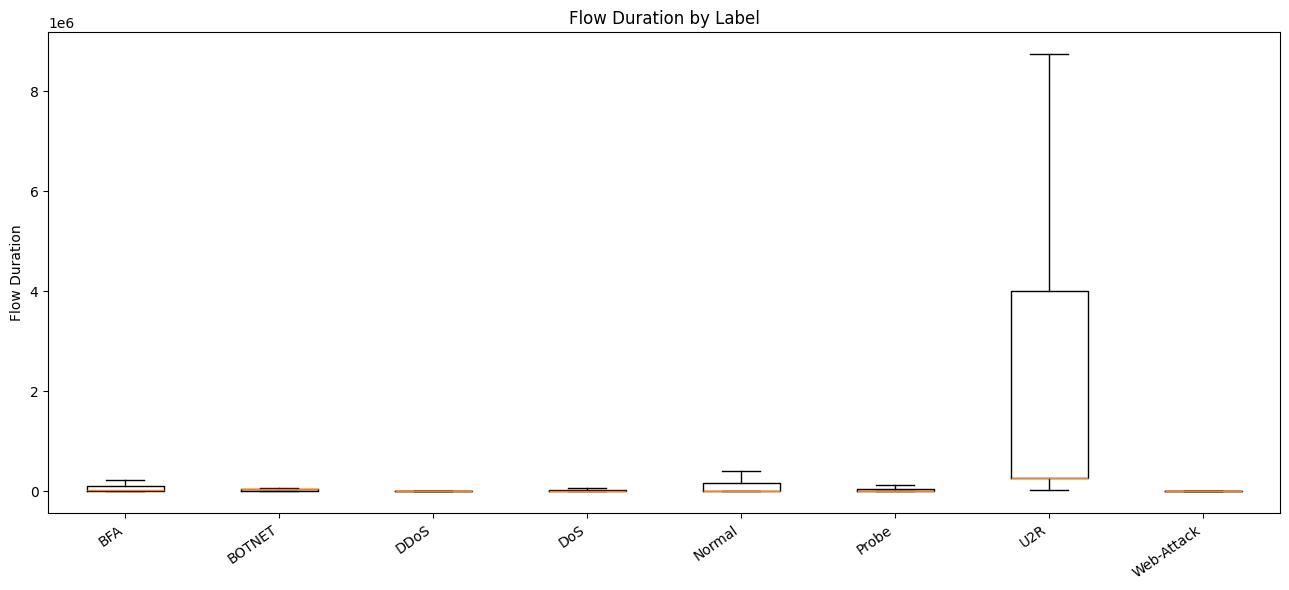

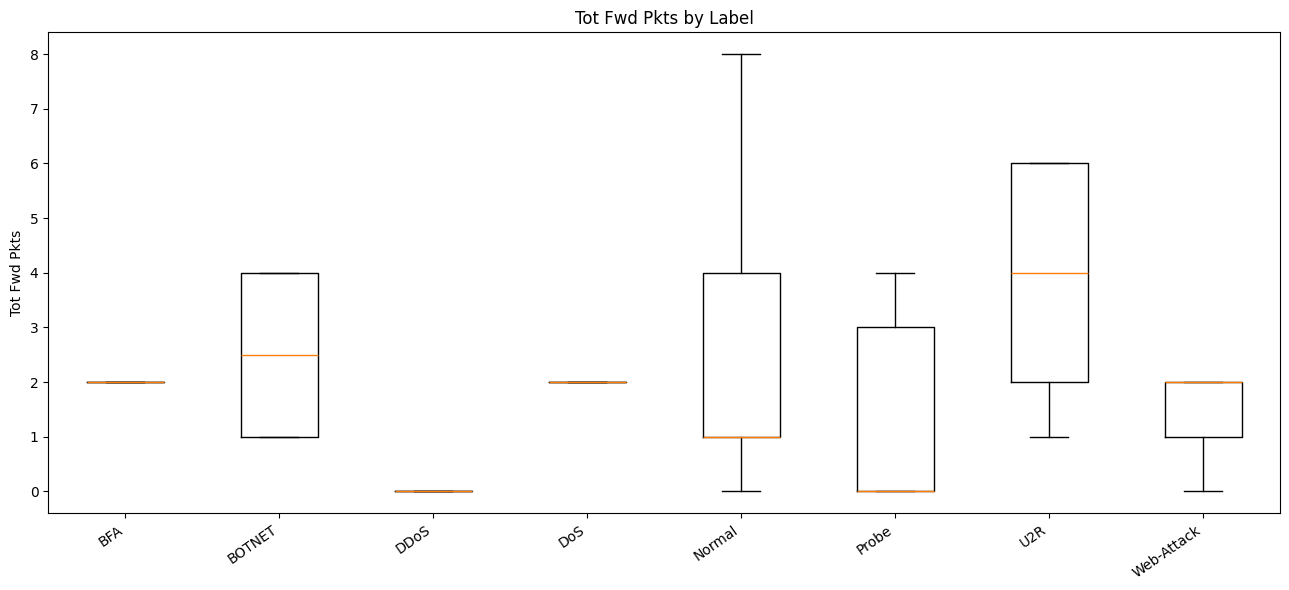

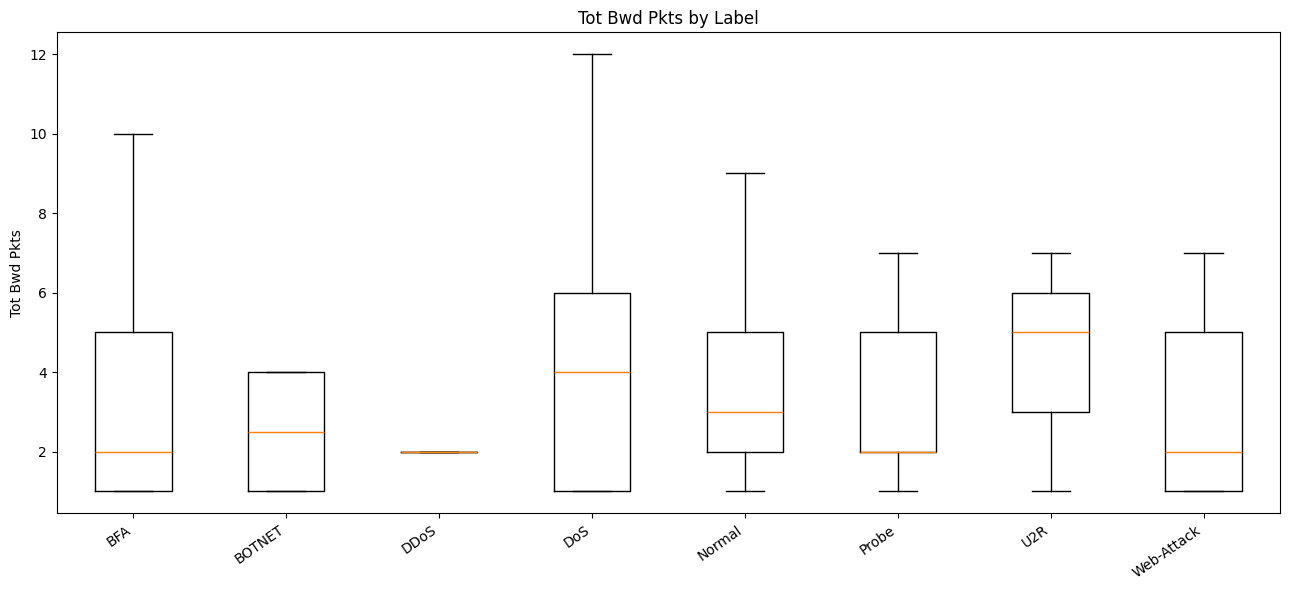

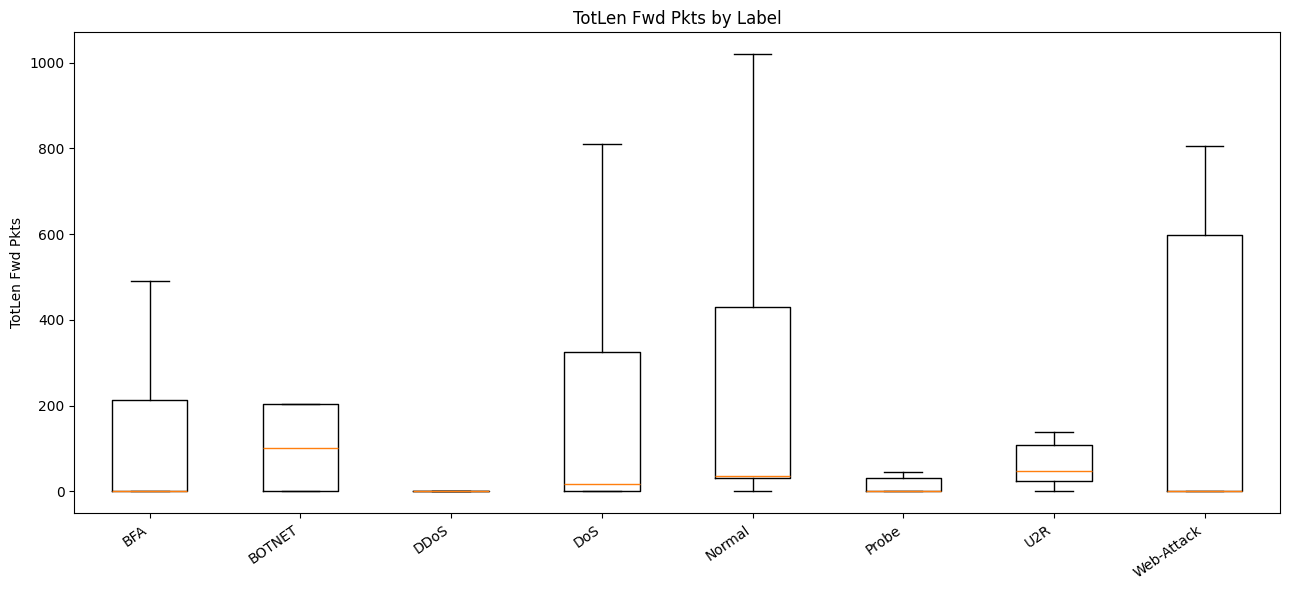

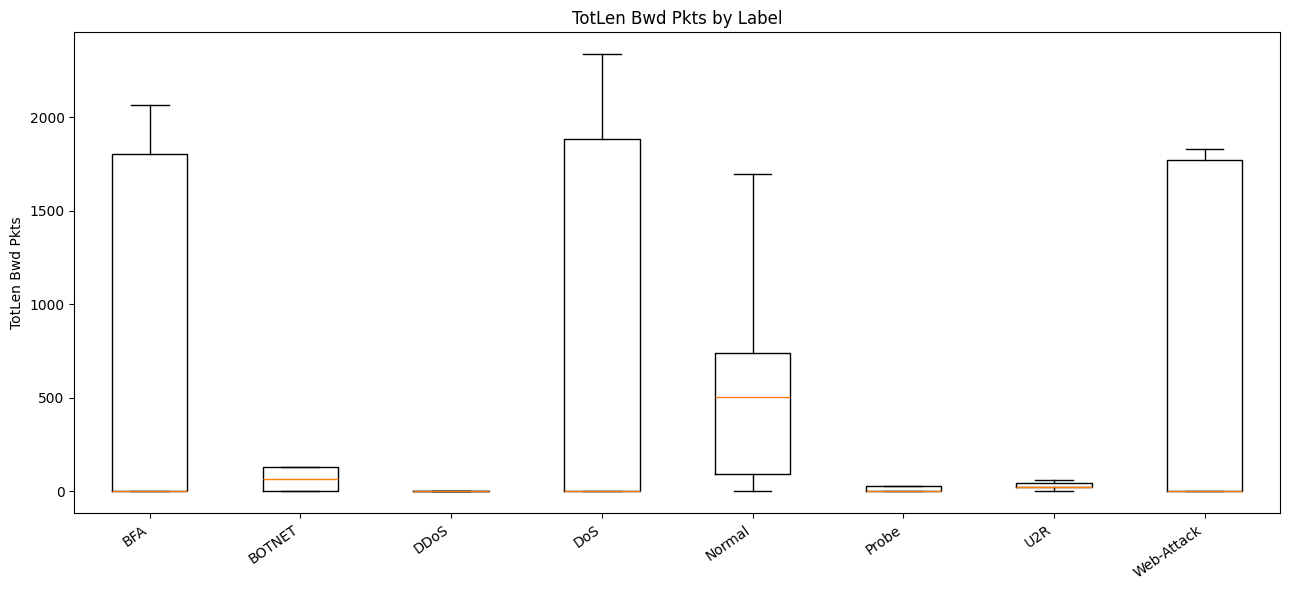

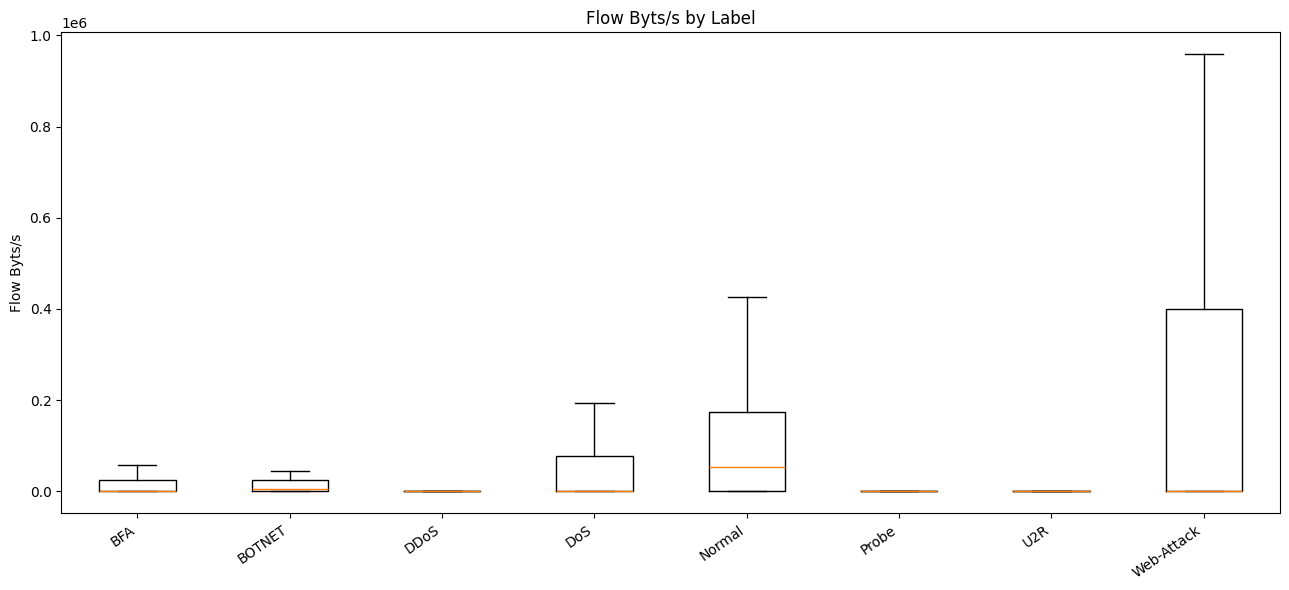

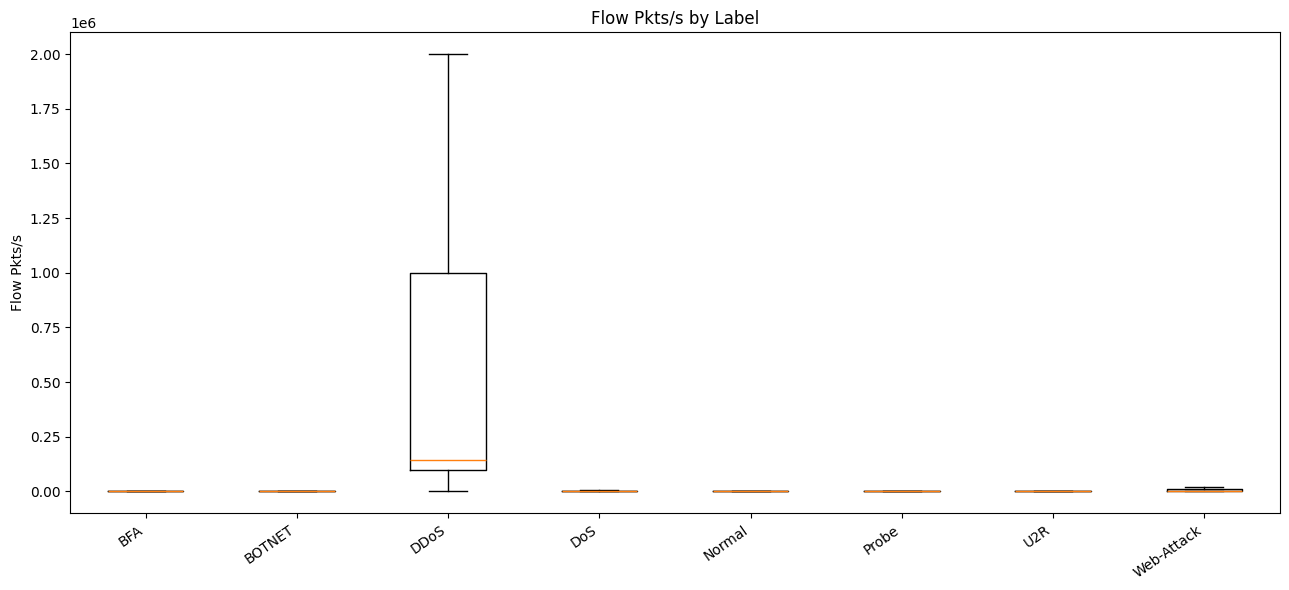

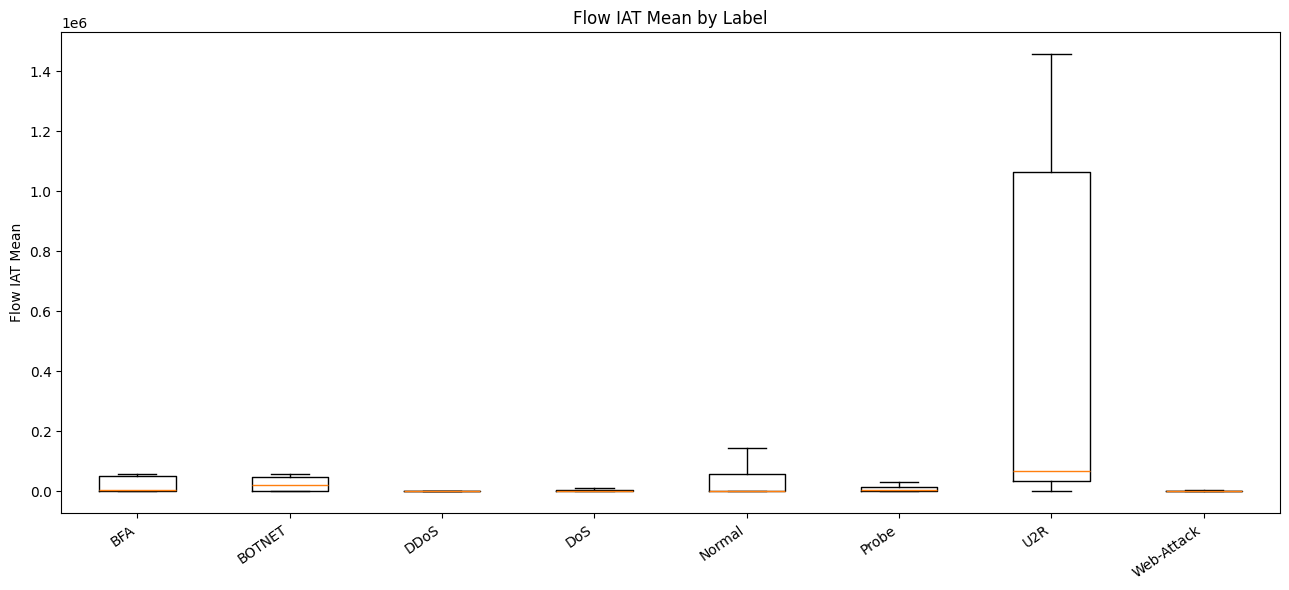

In [22]:
rng = np.random.default_rng(42)

box_features = available_features[:8]

for col in box_features:
    working = df[["Label", col]].copy()
    working[col] = pd.to_numeric(working[col], errors="coerce")
    working = working.replace([np.inf, -np.inf], np.nan).dropna()

    sampled_parts = []

    for label, group in working.groupby("Label"):
        if len(group) > 5000:
            sampled_idx = rng.choice(group.index.to_numpy(), size=5000, replace=False)
            group = group.loc[sampled_idx]

        sampled_parts.append(group)

    sampled = pd.concat(sampled_parts)

    upper = sampled[col].quantile(0.99)
    sampled = sampled[sampled[col] <= upper]

    labels = list(sampled["Label"].unique())
    arrays = [
        sampled.loc[sampled["Label"] == label, col].to_numpy()
        for label in labels
    ]

    plt.figure(figsize=(13, 6))
    plt.boxplot(arrays, labels=labels, showfliers=False)
    plt.title(f"{col} by Label")
    plt.ylabel(col)
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    plt.show()

## 19. Constant / zero-variance features

Các feature chỉ có một giá trị không giúp ích cho model.

In [23]:
numeric_only = df.select_dtypes(include=np.number)

nunique_numeric = numeric_only.nunique(dropna=False)

constant_features = nunique_numeric[nunique_numeric <= 1]

display(constant_features.to_frame("n_unique"))

,n_unique
Fwd PSH Flags,1
Fwd URG Flags,1
CWE Flag Count,1
ECE Flag Cnt,1
Fwd Byts/b Avg,1
Fwd Pkts/b Avg,1
Fwd Blk Rate Avg,1
Bwd Byts/b Avg,1
Bwd Pkts/b Avg,1
Bwd Blk Rate Avg,1


## 20. Feature skewness

In [24]:
clean_numeric = (
    numeric_only
    .replace([np.inf, -np.inf], np.nan)
)

skewness = clean_numeric.skew().sort_values(
    key=lambda s: s.abs(),
    ascending=False
)

display(skewness.head(30).to_frame("skewness"))

,skewness
Tot Fwd Pkts,585.169381
Subflow Fwd Pkts,585.169381
TotLen Fwd Pkts,326.034487
Subflow Fwd Byts,325.653448
Fwd Header Len,174.564337
Subflow Bwd Byts,163.859549
TotLen Bwd Pkts,163.370661
Tot Bwd Pkts,158.612697
Subflow Bwd Pkts,158.612697
Bwd Header Len,153.121328


## 21. Correlation giữa numeric features

Dùng **Spearman correlation** vì traffic features thường không Gaussian và có outlier.

In [25]:
corr_data = (
    clean_numeric
    .dropna(axis=1, how="all")
)

corr_data = corr_data.loc[:, corr_data.nunique(dropna=True) > 1]

corr = corr_data.corr(method="spearman")

mask = np.triu(np.ones(corr.shape), k=1).astype(bool)

corr_pairs = (
    corr.where(mask)
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "spearman_corr"]
corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()

high_corr = corr_pairs[
    corr_pairs["abs_corr"] >= 0.90
].sort_values("abs_corr", ascending=False)

display(high_corr.head(50))

,feature_1,feature_2,spearman_corr,abs_corr
306,Tot Fwd Pkts,Subflow Fwd Pkts,1.000000,1.000000
369,Tot Bwd Pkts,Subflow Bwd Pkts,1.000000,1.000000
428,TotLen Fwd Pkts,Subflow Fwd Byts,1.000000,1.000000
870,Bwd Pkt Len Mean,Bwd Seg Size Avg,1.000000,1.000000
655,Fwd Pkt Len Mean,Fwd Seg Size Avg,1.000000,1.000000
1664,Bwd URG Flags,URG Flag Cnt,1.000000,1.000000
1629,Bwd PSH Flags,PSH Flag Cnt,1.000000,1.000000
489,TotLen Bwd Pkts,Subflow Bwd Byts,1.000000,1.000000
1886,Pkt Len Std,Pkt Len Var,1.000000,1.000000
2206,Idle Mean,Idle Max,0.999988,0.999988


## 22. Correlation heatmap

Chỉ vẽ 25 feature có variance lớn nhất để heatmap không quá rối.

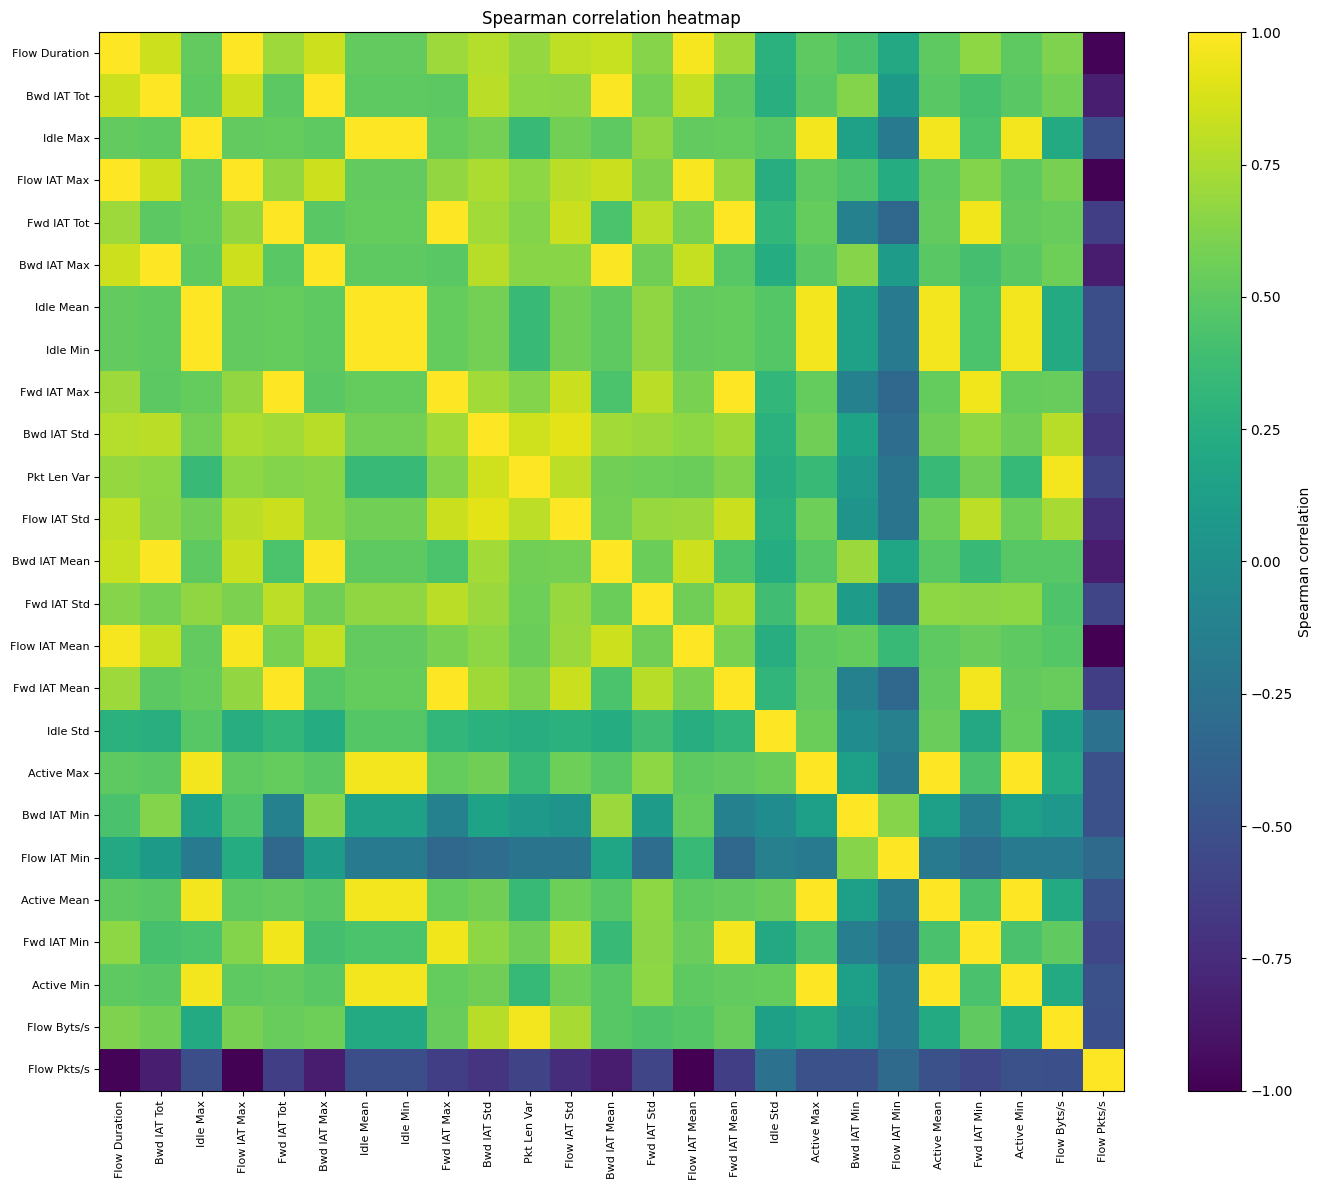

In [26]:
variances = corr_data.var().sort_values(ascending=False)

selected = variances.head(min(25, len(variances))).index

corr_small = corr_data[selected].corr(method="spearman")

plt.figure(figsize=(14, 12))
plt.imshow(corr_small, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Spearman correlation")

plt.xticks(
    range(len(selected)),
    selected,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(selected)),
    selected,
    fontsize=8
)

plt.title("Spearman correlation heatmap")
plt.tight_layout()
plt.show()

## 23. Timestamp analysis

Nếu `Timestamp` parse được, xem số flow theo phút.

Các spike lớn có thể liên quan đến DDoS / DoS / scan, nhưng spike **không tự động = attack**.

In [27]:
if "Timestamp" in df.columns:
    timestamps = pd.to_datetime(
        df["Timestamp"],
        errors="coerce",
        dayfirst=True
    )

    print("Parse success:", round(timestamps.notna().mean() * 100, 2), "%")
    print("Min:", timestamps.min())
    print("Max:", timestamps.max())

Parse success: 75.05 %
Min: 2020-01-01 22:25:00
Max: 2020-02-07 19:53:00


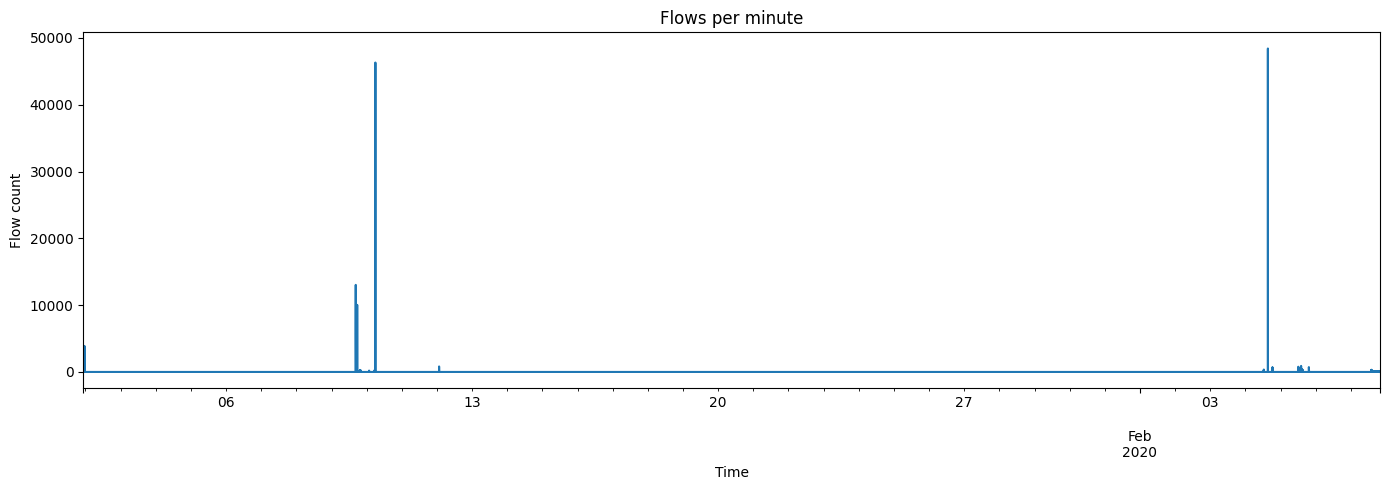

In [28]:
if "Timestamp" in df.columns:
    temp = df.copy()
    temp["Timestamp_parsed"] = pd.to_datetime(
        temp["Timestamp"],
        errors="coerce",
        dayfirst=True
    )

    temp = temp.dropna(subset=["Timestamp_parsed"])

    if len(temp) > 0:
        flows_per_minute = (
            temp.set_index("Timestamp_parsed")
            .resample("1min")
            .size()
        )

        plt.figure(figsize=(14, 5))
        flows_per_minute.plot()
        plt.title("Flows per minute")
        plt.xlabel("Time")
        plt.ylabel("Flow count")
        plt.tight_layout()
        plt.show()

## 24. Normal vs Attack

Với project anomaly detection, bạn có thể tạo binary target chỉ để **phân tích**, chưa train ở bước này.

Kiểm tra tên chính xác của class Normal trước khi chạy.

In [29]:
df["Label"].value_counts()

Label
DDoS          121942
Probe          98129
Normal         68424
DoS            53616
BFA             1405
Web-Attack       192
BOTNET           164
U2R               17
Name: count, dtype: int64

,count
BinaryLabel,
Attack,275465
Normal,68424


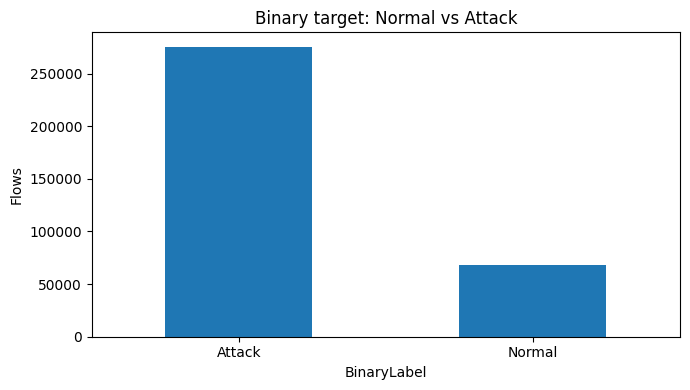

In [30]:
NORMAL_LABEL = "Normal"

df["BinaryLabel"] = np.where(
    df["Label"].str.lower() == NORMAL_LABEL.lower(),
    "Normal",
    "Attack"
)

binary_counts = df["BinaryLabel"].value_counts()

display(binary_counts.to_frame("count"))

plt.figure(figsize=(7, 4))
binary_counts.plot(kind="bar")
plt.title("Binary target: Normal vs Attack")
plt.ylabel("Flows")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 25. Feature median: Normal vs Attack

In [31]:
binary_medians = (
    df.groupby("BinaryLabel")[available_features]
    .median(numeric_only=True)
)

display(binary_medians)

,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Fwd Pkts/s,Bwd Pkts/s,Pkt Len Mean,Pkt Len Std,Pkt Len Var,Pkt Size Avg,SYN Flag Cnt,ACK Flag Cnt,RST Flag Cnt,Active Mean,Idle Mean
BinaryLabel,,,,,,,,,,,,,,,,,,,,
Attack,152.0,0.0,2.0,0.0,0.0,0.000000,16393.442620,105.000000,0.000000,0.000000,8547.008547,0.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0,0.0
Normal,4799.0,1.0,3.0,36.0,502.0,74484.930725,791.765637,1756.666667,1963.306649,186.654225,515.074517,136.4,149.834732,22450.44697,170.5,0.0,0.0,0.0,0.0,0.0


## 26. Checklist sau khi EDA

Sau khi chạy notebook này, bạn nên trả lời được:

### Data quality

- Có NaN không?
- Có `inf` không?
- Có duplicate không?
- Có constant features không?

### Target

- Có bao nhiêu attack class?
- Class imbalance nghiêm trọng đến mức nào?
- Binary `Normal vs Attack` có imbalance không?

### Network behavior

- Protocol nào phổ biến?
- Port nào xuất hiện nhiều?
- Attack nào có packet rate cao?
- Attack nào có duration ngắn?
- Attack nào có flow size bất thường?
- Các flag như SYN / ACK / RST khác Normal thế nào?

### Leakage

Đặc biệt kiểm tra:

```text
Flow ID
Src IP
Dst IP
Src Port
Dst Port
Timestamp
```

Nếu các identifier gắn chặt với attack label, model có thể học thuộc lab topology.

### Feature redundancy

- Feature nào correlation > 0.90?
- Có thể loại bớt feature tương đương nhau không?

---